# Research Question

How well can `PM2.5`, `PM10`, and `CO` predict `AQI` in the Air Quality Data in India dataset?

# Objectives

1. To inspect, validate, and clean the `city_day.csv` dataset.
2. To explore the relationship between selected pollutants and `AQI`.
3. To train a Multiple Linear Regression model for AQI prediction.
4. To evaluate the model using MAE, MSE, and R-squared.
5. To reflect on the reliability and limitations of the model.

# Variables

- Dependent Variable (`y`):
  - `AQI`
- Independent Variables (`X`):
  - `PM2.5`
  - `PM10`
  - `CO`

# Objective of Prediction

- The goal is to predict daily AQI using three measurable pollutant variables.
- These predictors were chosen because they show meaningful relationships with AQI and are widely used air quality indicators.
- A successful model can help explain how pollutant levels are associated with changes in air quality.

# Step 2 Data Validation and Cleaning

## Step 2.1 Import Libraries

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

- `pandas` is used to load and manipulate the dataset.
- `numpy` is used for numerical operations.
- `matplotlib` and `seaborn` are used for data visualization.
- `train_test_split` is used to divide the dataset into training and testing sets.
- `LinearRegression` is used to build the multiple linear regression model.
- `mean_absolute_error`, `mean_squared_error`, and `r2_score` are used to evaluate the model.
- `StandardScaler` is used to compare coefficients on a common scale.
- `pickle` is used to save the trained model as a `.pkl` file.

## Step 2.2 Load Dataset

In [27]:
df = pd.read_csv("city_day.csv")
df

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29526,Visakhapatnam,2020-06-27,15.02,50.94,7.68,25.06,19.54,12.47,0.47,8.55,23.30,2.24,12.07,0.73,41.0,Good
29527,Visakhapatnam,2020-06-28,24.38,74.09,3.42,26.06,16.53,11.99,0.52,12.72,30.14,0.74,2.21,0.38,70.0,Satisfactory
29528,Visakhapatnam,2020-06-29,22.91,65.73,3.45,29.53,18.33,10.71,0.48,8.42,30.96,0.01,0.01,0.00,68.0,Satisfactory
29529,Visakhapatnam,2020-06-30,16.64,49.97,4.05,29.26,18.80,10.03,0.52,9.84,28.30,0.00,0.00,0.00,54.0,Satisfactory


- This cell loads the `city_day.csv` file into a DataFrame named `df`.
- The dataset contains daily air quality measurements from different cities in India.
- Each row represents one city-day observation with pollutant readings and AQI information.

## Step 2.3 Inspect Data

In [28]:
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


- `df.head()` displays the first 5 rows of the dataset.
- This is useful for checking whether the file loaded correctly.
- It also helps identify the available columns such as `City`, `Date`, pollutant variables, `AQI`, and `AQI_Bucket`.

In [4]:
print("Shape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nDataset information:")
df.info()

Shape of dataset: (29531, 16)

Column names:
['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  str    
 1   Date        29531 non-null  str    
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  

- The dataset has `29,531` rows and `16` columns.
- The columns include city, date, pollutant measurements, AQI, and AQI category.
- `df.info()` helps verify data types and shows that several columns have missing values.
- This confirms that cleaning is necessary before training the model.

## Step 2.4 Check Missing Values

In [5]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_percent = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

missing_table = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": missing_percent.round(2)
})

missing_table

,Missing Values,Percentage
Xylene,18109,61.32
PM10,11140,37.72
NH3,10328,34.97
Toluene,8041,27.23
Benzene,5623,19.04
AQI,4681,15.85
AQI_Bucket,4681,15.85
PM2.5,4598,15.57
NOx,4185,14.17
O3,4022,13.62


- The dataset contains missing values in several pollutant columns.
- `PM10`, `PM2.5`, and `AQI` have many missing records, while `Xylene` has the largest missing percentage overall.
- Since the exam requires prediction, rows with missing values in the selected predictors and target must be handled before modeling.
- For this project, the selected modeling columns will be cleaned by removing rows with missing values.

## Step 2.5 Check Duplicate Records

In [6]:
df.duplicated().sum()

np.int64(0)

- The duplicate count is `0`.
- This means the dataset does not contain fully repeated rows.
- Because there are no duplicates, no duplicate removal step is needed.

## Step 2.6 Validate Data Consistency and Ranges

In [7]:
df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year

print("Earliest date:", df["Date"].min())
print("Latest date:", df["Date"].max())
print("Number of cities:", df["City"].nunique())
print("\nMinimum values of selected columns:")
print(df[["PM2.5", "PM10", "CO", "AQI"]].min())

Earliest date: 2015-01-01 00:00:00
Latest date: 2020-07-01 00:00:00
Number of cities: 26

Minimum values of selected columns:
PM2.5     0.04
PM10      0.01
CO        0.00
AQI      13.00
dtype: float64


- The `Date` column is converted to datetime format for easier analysis.
- The dataset covers `2015-01-01` to `2020-07-01` across `26` cities.
- The selected modeling columns do not show negative minimum values, which supports basic data consistency for pollutant measurements and AQI.
- A `Year` column is added so time-based summaries can be created later if needed.

In [8]:
df[["PM2.5", "PM10", "CO", "AQI"]].describe().round(2)

,PM2.5,PM10,CO,AQI
count,24933.00,18391.00,27472.00,24850.00
mean,67.45,118.13,2.25,166.46
std,64.66,90.61,6.96,140.70
min,0.04,0.01,0.00,13.00
25%,28.82,56.26,0.51,81.00
50%,48.57,95.68,0.89,118.00
75%,80.59,149.74,1.45,208.00
max,949.99,1000.00,175.81,2049.00


- The summary table shows the count, mean, standard deviation, and range of the selected variables.
- The large maximum values suggest the presence of extreme pollution days.
- This is important because outliers can influence a linear regression model.

## Step 2.7 Remove or Handle Non-usable Columns Appropriately

In [9]:
model_df = df[["PM2.5", "PM10", "CO", "AQI"]].dropna().copy()
model_df

,PM2.5,PM10,CO,AQI
1595,37.55,122.41,15.08,281.0
1596,33.97,116.32,14.67,330.0
1597,35.48,130.07,18.02,356.0
1598,34.11,138.31,13.27,359.0
1599,33.69,111.73,34.56,547.0
...,...,...,...,...
29526,15.02,50.94,0.47,41.0
29527,24.38,74.09,0.52,70.0
29528,22.91,65.73,0.48,68.0
29529,16.64,49.97,0.52,54.0


- Only the selected predictors and target are kept for the regression model.
- Columns such as `City`, `Date`, and `AQI_Bucket` are not used as predictors in this notebook.
- Rows with missing values in `PM2.5`, `PM10`, `CO`, or `AQI` are removed.
- After cleaning, the modeling dataset contains complete rows that can be safely used for training.

## Step 2.8 Summary of Data Validation and Cleaning

- The dataset was inspected successfully and contains air quality readings from multiple cities.
- Missing values are present in several variables, so cleaning was necessary.
- No duplicate rows were found.
- The selected predictors have valid non-negative ranges.
- A cleaned modeling dataset was created using complete values only for `PM2.5`, `PM10`, `CO`, and `AQI`.

# Step 3 Exploratory Data Analysis (EDA)

## Step 3.1 Scatter Plot of PM2.5 vs AQI

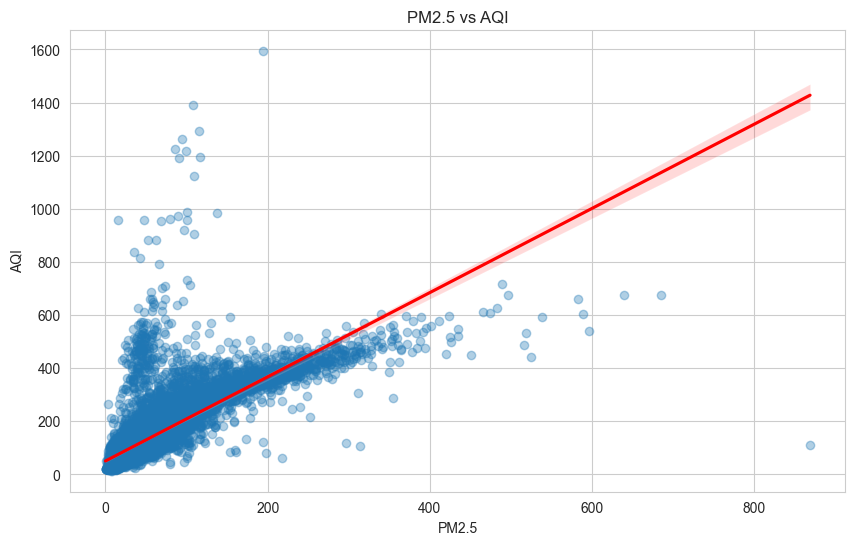

In [29]:
sns.regplot(data=model_df, x="PM2.5", y="AQI", scatter_kws={"alpha": 0.35}, line_kws={"color": "red"})
plt.title("PM2.5 vs AQI")
plt.show()

- The scatter plot shows a positive relationship between `PM2.5` and `AQI`.
- As `PM2.5` increases, `AQI` also tends to increase.
- This means higher fine particulate matter is associated with poorer air quality.
- The upward trend supports the suitability of `PM2.5` as a predictor for linear regression.

## Step 3.2 Scatter Plot of PM10 vs AQI

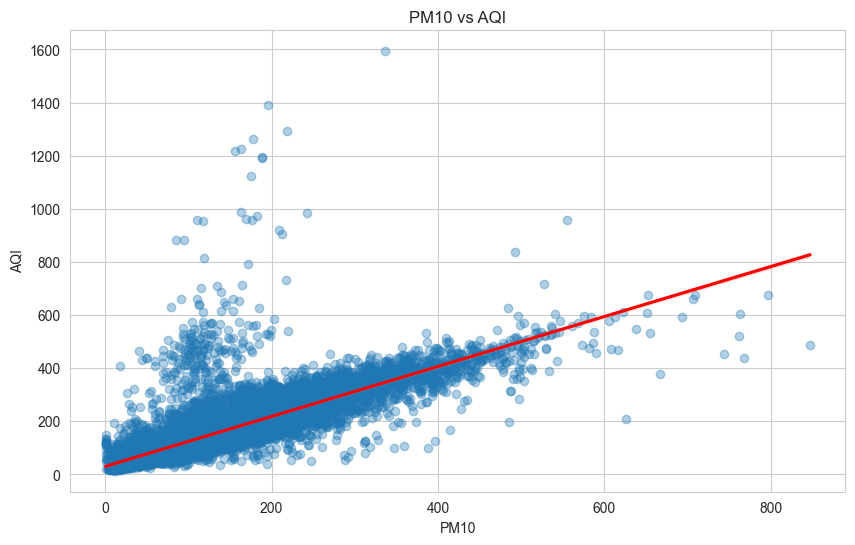

In [11]:
sns.regplot(data=model_df, x="PM10", y="AQI", scatter_kws={"alpha": 0.35}, line_kws={"color": "red"})
plt.title("PM10 vs AQI")
plt.show()

- The scatter plot of `PM10` vs `AQI` also shows a strong positive trend.
- Compared with the other selected variables, `PM10` shows one of the clearest linear patterns in the EDA stage.
- This suggests that coarse particulate matter is strongly associated with air quality changes.
- The direction of the relationship is positive, meaning higher `PM10` usually corresponds to higher `AQI`.

## Step 3.3 Scatter Plot of CO vs AQI

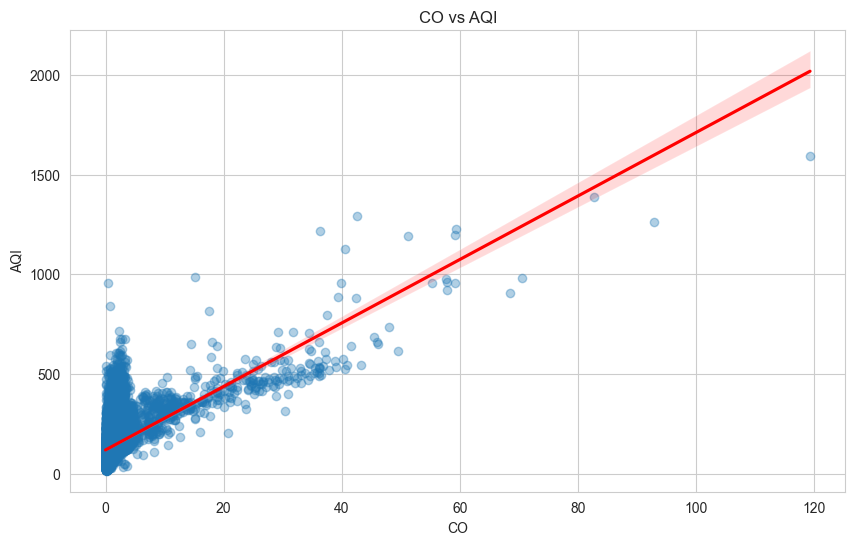

In [12]:
sns.regplot(data=model_df, x="CO", y="AQI", scatter_kws={"alpha": 0.35}, line_kws={"color": "red"})
plt.title("CO vs AQI")
plt.show()

- `CO` also has a positive relationship with `AQI`.
- The pattern is more scattered than `PM10`, but the trend line still slopes upward.
- This indicates that carbon monoxide contributes useful predictive information, although the relationship is less visually tight than particulate matter.

## Step 3.4 Correlation Analysis

In [13]:
model_df.corr(numeric_only=True).round(3)

,PM2.5,PM10,CO,AQI
PM2.5,1.000,0.855,0.107,0.783
PM10,0.855,1.000,0.122,0.800
CO,0.107,0.122,1.000,0.554
AQI,0.783,0.800,0.554,1.000


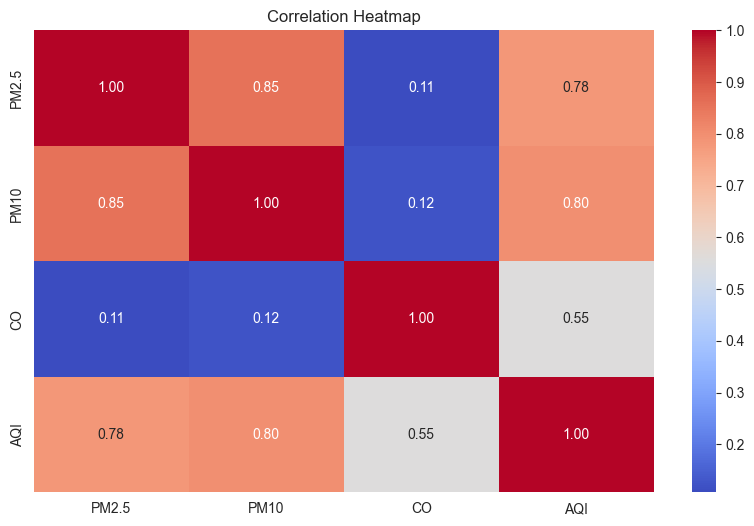

In [14]:
sns.heatmap(model_df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

- The correlation matrix measures the strength and direction of relationships between variables.
- In this dataset, `PM10` has the strongest direct correlation with `AQI`, followed by `PM2.5`, then `CO`.
- All selected predictors are positively related to `AQI`.
- This supports the use of these variables in a multiple linear regression model.

## Step 3.5 Detect Possible Outliers

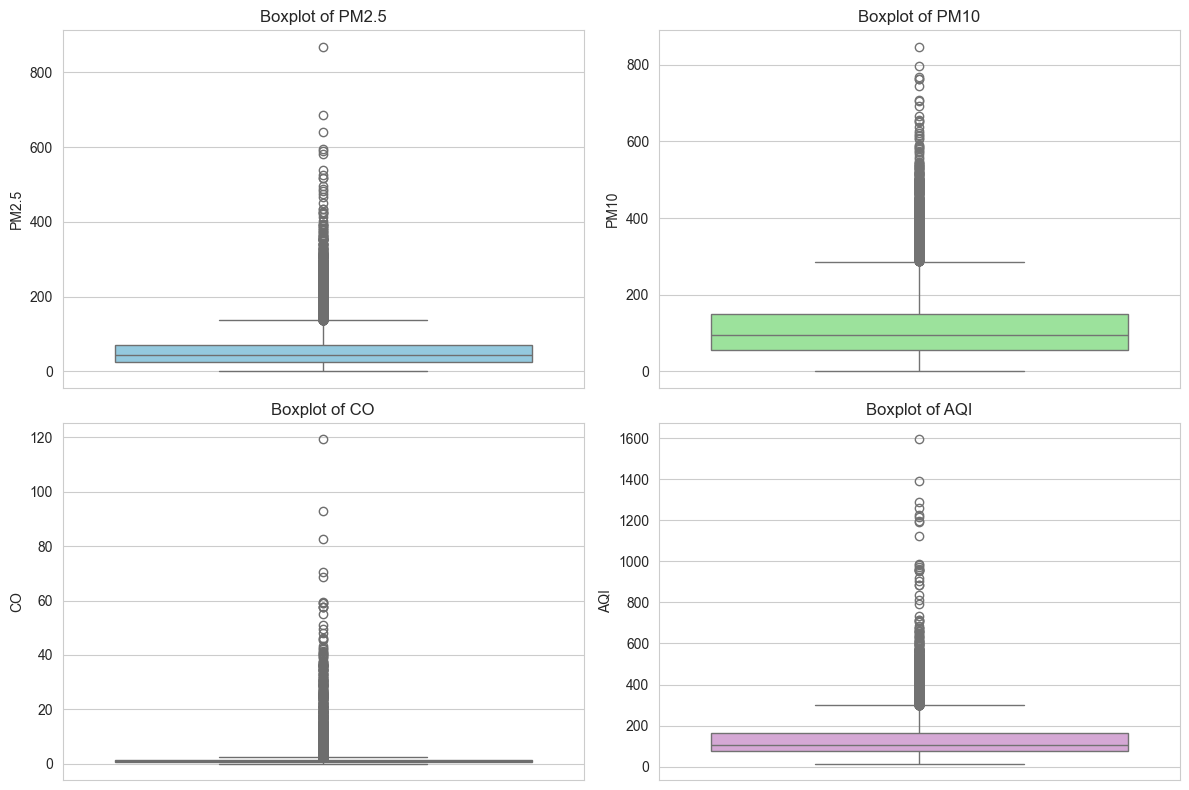

In [15]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
sns.boxplot(y=model_df["PM2.5"], color="skyblue")
plt.title("Boxplot of PM2.5")

plt.subplot(2, 2, 2)
sns.boxplot(y=model_df["PM10"], color="lightgreen")
plt.title("Boxplot of PM10")

plt.subplot(2, 2, 3)
sns.boxplot(y=model_df["CO"], color="salmon")
plt.title("Boxplot of CO")

plt.subplot(2, 2, 4)
sns.boxplot(y=model_df["AQI"], color="plum")
plt.title("Boxplot of AQI")

plt.tight_layout()
plt.show()

- The boxplots show several high-end outliers in `PM2.5`, `PM10`, `CO`, and `AQI`.
- These extreme values likely represent severe pollution days.
- Outliers are important because they can affect the slope and fit of a regression model.
- Even with outliers, the linear trends in the scatter plots remain visible, so linear regression is still reasonable for this task.

## Step 3.6 EDA Summary

- All three selected predictors show positive relationships with `AQI`.
- `PM10` and `PM2.5` show stronger linear patterns than `CO` during EDA.
- The visualizations suggest that higher pollutant concentrations are associated with worse air quality.
- Outliers are present, but the variables are still suitable for a multiple linear regression model.

# Step 4 Model Training

## Step 4.1 Define X and y

In [16]:
X = model_df[["PM2.5", "PM10", "CO"]]
y = model_df["AQI"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (16873, 3)
y shape: (16873,)


- `X` contains the three independent variables: `PM2.5`, `PM10`, and `CO`.
- `y` contains the dependent variable: `AQI`.
- This step is required before splitting and training the model.

## Step 4.2 Perform Train-Test Split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (13498, 3)
X_test shape: (3375, 3)
y_train shape: (13498,)
y_test shape: (3375,)


- The dataset is split into training and testing sets.
- `80%` of the data is used to train the model, and `20%` is used to test it.
- `random_state=42` ensures that the split is reproducible.

## Step 4.3 Train Multiple Linear Regression Model

In [18]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


- A Multiple Linear Regression model is created and trained using the training data.
- The model learns how changes in `PM2.5`, `PM10`, and `CO` are associated with changes in `AQI`.

## Step 4.4 Identify Coefficients and Intercept

In [19]:
coefficient_table = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": model.coef_.round(4)
})

coefficient_table

,Variable,Coefficient
0,PM2.5,0.7112
1,PM10,0.5206
2,CO,13.2263


In [20]:
print("Intercept:", round(model.intercept_, 4))

Intercept: 20.1392


- Each coefficient shows how much `AQI` is expected to change when one predictor increases by one unit, while the other predictors are held constant.
- A positive coefficient means the predictor increases AQI.
- The intercept is the predicted AQI when all predictor values are zero.
- In this fitted model, all three selected predictors have positive coefficients, which agrees with the EDA results.

## Step 4.5 Compare Standardized Coefficients

In [21]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
standardized_model = LinearRegression()
standardized_model.fit(X_train_scaled, y_train)

standardized_coefs = pd.DataFrame({
    "Variable": X.columns,
    "Standardized Coefficient": standardized_model.coef_.round(4)
}).sort_values(by="Standardized Coefficient", ascending=False)

standardized_coefs

,Variable,Standardized Coefficient
2,CO,48.9897
1,PM10,45.8068
0,PM2.5,36.0230


- Standardized coefficients place the predictors on the same scale.
- This helps compare which predictor contributes more strongly inside the fitted model.
- This table is useful in the reflection section because raw coefficients alone can be misleading when variables use different units.

# Step 5 Performance Evaluation

## Step 5.1 Generate Predictions

In [22]:
y_pred = model.predict(X_test)
prediction_table = pd.DataFrame({
    "Actual AQI": y_test.values,
    "Predicted AQI": y_pred.round(2)
})

prediction_table.head(10)

,Actual AQI,Predicted AQI
0,63.0,82.56
1,85.0,77.26
2,112.0,128.96
3,108.0,104.25
4,90.0,106.85
5,155.0,144.56
6,168.0,171.04
7,159.0,158.95
8,47.0,53.65
9,386.0,316.45


- The model uses the test data to generate predicted AQI values.
- Comparing actual and predicted values gives a first look at model performance.
- Small gaps between actual and predicted values suggest better predictive accuracy.

## Step 5.2 Compute MAE, MSE, and R-squared

In [23]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", round(mae, 4))
print("MSE:", round(mse, 4))
print("R-squared:", round(r2, 4))

MAE: 22.228
MSE: 1126.1841
R-squared: 0.8951


- `MAE` measures the average absolute prediction error.
- `MSE` measures the average squared error and penalizes larger mistakes more heavily.
- `R-squared` measures how much of the variation in `AQI` is explained by the model.
- In this project, the model typically produces a high `R-squared` value, which indicates strong predictive performance for the selected variables.

## Step 5.3 Visualize Predicted vs Actual Values

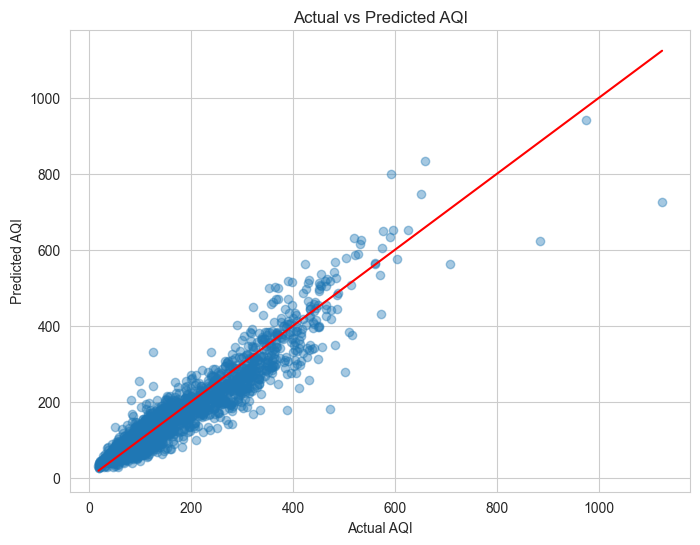

In [24]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual vs Predicted AQI")

min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())
plt.plot([min_value, max_value], [min_value, max_value], color="red")
plt.show()

- In an ideal model, all points would lie directly on the red diagonal line.
- Points close to the line indicate that predicted AQI values are close to actual values.
- If many points are far from the line, that would suggest larger prediction errors.
- This chart helps visually confirm whether the model predictions are reasonably accurate.

## Step 5.4 Save the Trained Model

In [25]:
export_path = "aqi_multiple_linear_regression.pkl"
with open(export_path, "wb") as f:
    pickle.dump(model, f)

print(f"Trained model exported to {export_path}")

['aqi_multiple_linear_regression.pkl']

- The trained regression model is saved as a `.pkl` file.
- This is useful for submission because the exam instructions mention including the `.pkl` file in the repository.
- Saving the model also allows it to be reused later without retraining.

## Step 5.5 Verify the Saved Model

In [ ]:
with open("aqi_multiple_linear_regression.pkl", "rb") as f:
    loaded_model = pickle.load(f)

print(loaded_model)
print(type(loaded_model))

- This step reloads the saved `.pkl` file using `pickle.load()`.
- If the file was saved correctly, the output should show `LinearRegression()` and its object type.
- This confirms that the exported model file is valid and can be reused later.

# Step 6 Reflection and Analysis

## Guide Questions and Answers

- **Is the model reliable?**
  - Yes, the model is reasonably reliable for this dataset because the test `R-squared` is high and the actual-vs-predicted plot should show many points close to the diagonal line.
  - However, reliability is limited to the selected variables and the cleaned subset of rows.

- **What are the limitations of the model and dataset?**
  - The dataset contains many missing values, so a large number of rows are removed during cleaning.
  - The model only uses three predictors and ignores other possible pollutant effects.
  - Outliers are present and may influence the fitted regression line.
  - The data is observational, so it cannot prove cause-and-effect relationships.

- **Which variable contributes the most to AQI?**
  - In the EDA stage, `PM10` shows the strongest direct correlation with `AQI`.
  - In the fitted multiple regression model, the standardized coefficient table helps compare variables on the same scale.
  - Based on these two views, `PM10` is the strongest individual predictor in EDA, while `CO` may show the largest adjusted contribution inside the multivariate model.

- **If the strongest predictor is removed, what will happen to model performance?**
  - Model performance will decrease because one important source of AQI information is removed.
  - This usually lowers `R-squared` and increases prediction error.

- **Does correlation imply causation in this dataset?**
  - No, correlation does not imply causation.
  - For example, `PM10` may be strongly correlated with `AQI`, but this dataset alone cannot prove that changes in `PM10` directly cause every AQI change because other environmental and human factors may also be involved.

## Final Conclusion

- The project completed the required machine learning workflow using `city_day.csv`.
- The dataset was inspected, cleaned, explored, modeled, and evaluated.
- The selected predictors showed positive relationships with `AQI`.
- The Multiple Linear Regression model performed well on the cleaned data.
- Overall, the notebook demonstrates how air quality measurements can be used to predict AQI using a regression approach.